In [1]:
# import necessary modules
from classy import Class
from math import pi
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

In [2]:
#############################################
#
# Cosmological parameters and other CLASS parameters
#
common_settings = {# LambdaCDM parameters
                   'h':0.67810,
                   'omega_b':0.02238280,
                   'omega_cdm':0.1201075,
                   'A_s':2.100549e-09,
                   'n_s':0.9660499,
                   'tau_reio':0.05430842 ,
                   # output and precision parameters
                   'output':'tCl,pCl,lCl',
                   'lensing':'yes',
                   'l_max_scalars':5000}
#
M = Class()
#
###############
#    
# call CLASS for the total Cl's and then for each contribution
#
###############
#
M.set(common_settings)
M.compute()
cl_tot = M.raw_cl(3000)
cl_lensed = M.lensed_cl(3000)
M.empty()           # reset input
#
M.set(common_settings) # new input
M.set({'temperature contributions':'tsw'}) 
M.compute()
cl_tsw = M.raw_cl(3000) 
M.empty()
#
M.set(common_settings)
M.set({'temperature contributions':'eisw'})
M.compute()
cl_eisw = M.raw_cl(3000) 
M.empty()
#
M.set(common_settings)
M.set({'temperature contributions':'lisw'})
M.compute()
cl_lisw = M.raw_cl(3000) 
M.empty()
#
M.set(common_settings)
M.set({'temperature contributions':'dop'})
M.compute()
cl_dop = M.raw_cl(3000) 
M.empty()

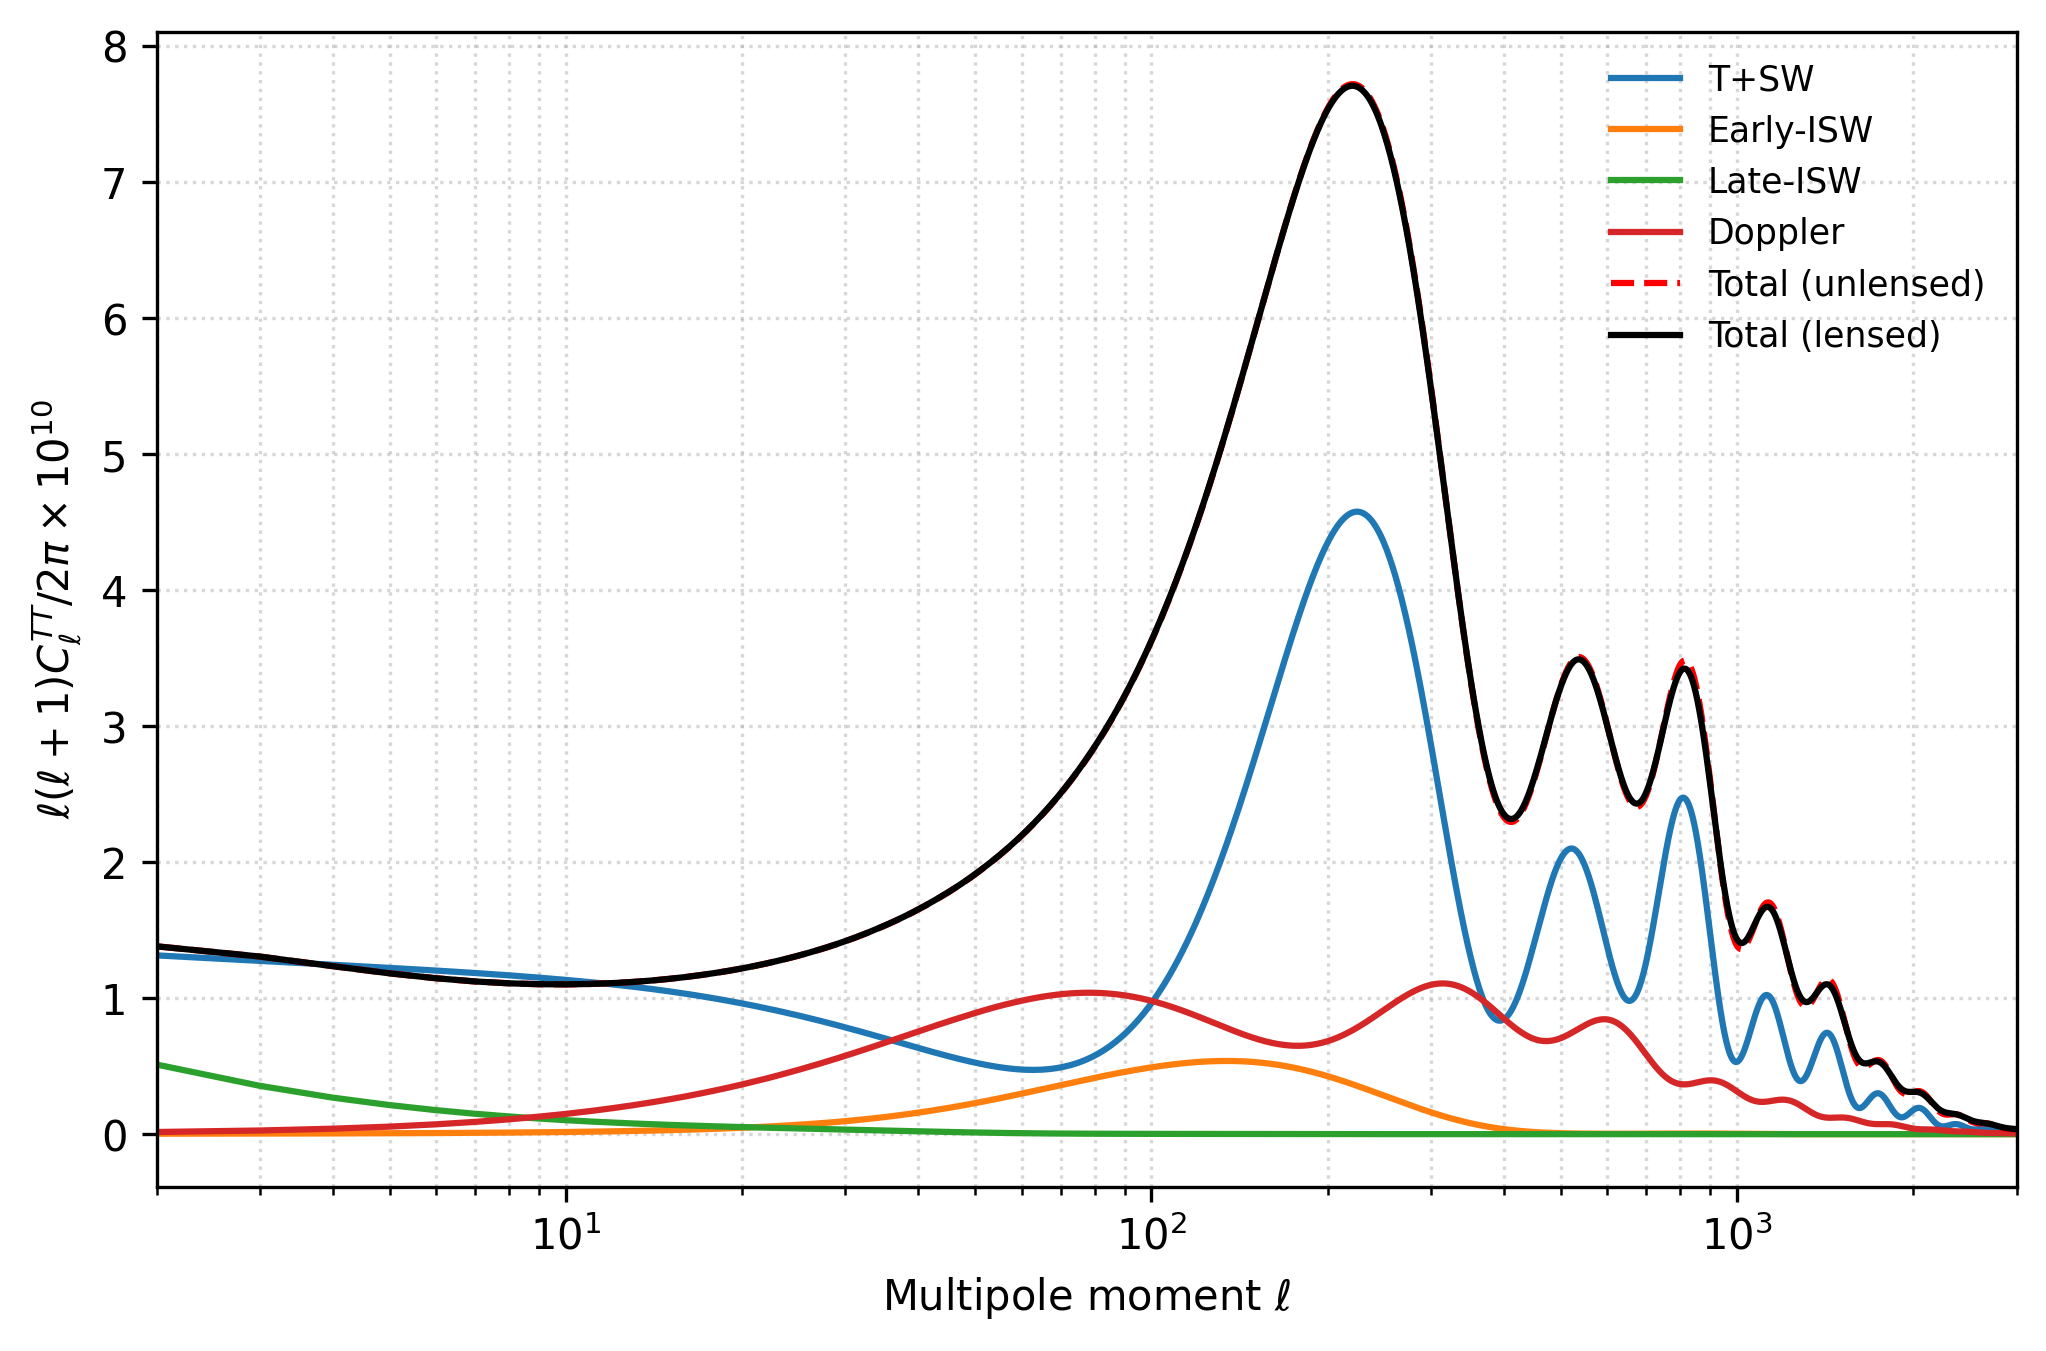

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Increase DPI for publication-ready sharpness
plt.rcParams['figure.dpi'] = 300 

fig, ax = plt.subplots(figsize=(8, 5))

# Physical factor for plotting D_l
ell = cl_tot['ell']
factor = 1.e10 * ell * (ell + 1.0) / (2.0 * np.pi)

# Using more distinct, professional colors
ax.semilogx(ell, factor * cl_tsw['tt'],    label='T+SW', color='#1f77b4')
ax.semilogx(ell, factor * cl_eisw['tt'],   label='Early-ISW', color='#ff7f0e')
ax.semilogx(ell, factor * cl_lisw['tt'],   label='Late-ISW', color='#2ca02c')
ax.semilogx(ell, factor * cl_dop['tt'],    label='Doppler', color='#d62728')

# Highlighting the totals with distinct line weights
ax.semilogx(ell, factor * cl_tot['tt'],    label='Total (unlensed)', color='red', linestyle='--')
ax.semilogx(ell, factor * cl_lensed['tt'], label='Total (lensed)', color='black', linewidth=1.5)

# Formatting
ax.set_xlim(2, 3000)
ax.set_xlabel(r"Multipole moment $\ell$")
ax.set_ylabel(r"$\ell(\ell+1)C_\ell^{TT} / 2\pi \times 10^{10}$")

# Grid with transparency to avoid "chartjunk"
ax.grid(True, which='both', linestyle=':', alpha=0.5)

# Position legend inside or clearly outside without overlapping saved margins
ax.legend(loc='upper right', frameon=False, fontsize='small')

# Save with tight layout to avoid clipped labels
plt.savefig('cltt_terms_refined.pdf', bbox_inches='tight')